# Mellinguer low level controller test

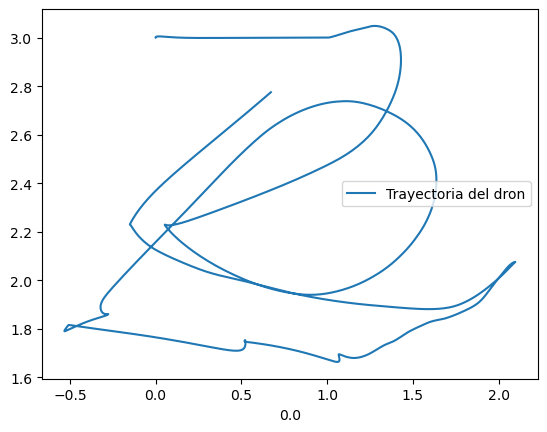

In [11]:
import numpy as np
import mujoco
from mujoco import viewer
import time
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, enforce_tilt_and_thrust_limits, get_drone_state, reset_episode, set_goal_for_episode
from plot import plot_trajectory

def quat_to_rotmat(q):
    """Quaternion (w,x,y,z) -> matriz de rotación 3x3."""
    w, x, y, z = q
    return np.array([
        [1 - 2*(y*y + z*z),     2*(x*y - z*w),     2*(x*z + y*w)],
        [    2*(x*y + z*w), 1 - 2*(x*x + z*z),     2*(y*z - x*w)],
        [    2*(x*z - y*w),     2*(y*z + x*w), 1 - 2*(x*x + y*y)]
    ], dtype=float)


# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/single_quadrotor_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "core")
if drone_id < 0:
    raise ValueError("No existe el body 'core' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerController(mass=m, gravity=9.81, gains=gains)
    # def __init__(
    #     self,
    #     mass,
    #     gravity,
    #     inertia,
    #     gains,
    #     acc_alpha=0.2,
    #     angacc_alpha=0.2,
    #     u1_limits=(0.0, None),
    #     moment_limits=None,


controller2 = INDIController(mass=m, gravity=9.81, gains=gains, inertia=np.array([0.01, 0.01, 0.02]))



# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")

# guardar para debug/visualización
vector_r = []
vector_rT = []
rT = p0.copy()  # referencia inicial
vel_prev = np.zeros(3)  # para estimación de aceleración

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = (vel_world - vel_prev) / dt
        vel_prev = vel_world.copy()

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # ---------------------------
        # (2) Referencia deseada (ejemplo: oscilación en x)
        # ---------------------------
        x_d = 1 #0.5 * np.sin(0.5 * t)
        x_dot_d = 0 #0.25 * np.cos(0.5 * t)
        x_ddot_d = 0 #-0.125 * np.sin(0.5 * t)

        rT = np.array([p0[0] + x_d, p0[1], p0[2]])
        vT = np.array([x_dot_d, 0.0, 0.0])
        aT = np.array([x_ddot_d, 0.0, 0.0])

        yaw_d = 0.0

        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u, Fv, Fe = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d)

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe, scale=0.03, max_len=0.8, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = dt - elapsed
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])


# # visualización de trayectoria (opcional)
# import matplotlib.pyplot as plt
# vector_r = np.array(vector_r)
# plt.figure()
# plt.plot(vector_r[:,0], vector_r[:,2], label='Trayectoria del dron')
# plt.xlabel('x (m)')
# plt.ylabel('z (m)')

# #ajustar límites y agregar referencia deseada
# # plt.xlim(p0[0] - 1, p0[0] + 1)
# # plt.ylim(p0[2] - 1, p0[2] + 1)

# plt.legend()
# plt.show()


# INDI low level controller test

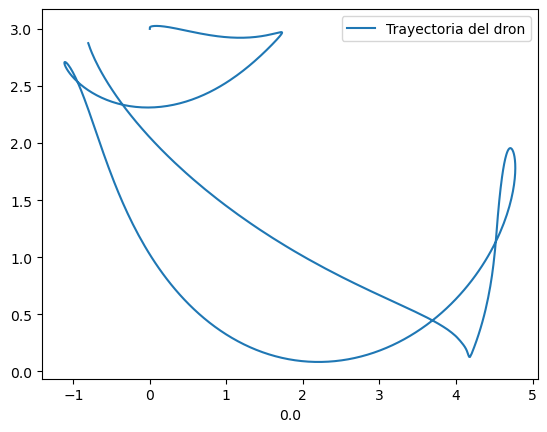

In [12]:
import numpy as np
import mujoco
from mujoco import viewer
import time
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, enforce_tilt_and_thrust_limits, get_drone_state, reset_episode, set_goal_for_episode
from plot import plot_trajectory

def quat_to_rotmat(q):
    """Quaternion (w,x,y,z) -> matriz de rotación 3x3."""
    w, x, y, z = q
    return np.array([
        [1 - 2*(y*y + z*z),     2*(x*y - z*w),     2*(x*z + y*w)],
        [    2*(x*y + z*w), 1 - 2*(x*x + z*z),     2*(y*z - x*w)],
        [    2*(x*z - y*w),     2*(y*z + x*w), 1 - 2*(x*x + y*y)]
    ], dtype=float)


# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/single_quadrotor_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "core")
if drone_id < 0:
    raise ValueError("No existe el body 'core' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([4.0, 4.0, 8.0]),   # Kp posición
    np.array([3.0, 3.0, 5.0]),   # Kv velocidad
    np.array([8.0, 8.0, 3.0]),   # KR actitud
    np.array([0.8, 0.8, 0.4]),   # Komega
]


mass = 1.0
gravity = 9.81
J = np.diag([0.02, 0.02, 0.04])

gains = [
    np.array([4.0, 4.0, 8.0]),   # Kp posición
    np.array([3.0, 3.0, 5.0]),   # Kv velocidad
    np.array([8.0, 8.0, 3.0]),   # KR actitud
    np.array([0.8, 0.8, 0.4]),   # Komega
]

controller2 = INDIController(
    mass=mass,
    gravity=gravity,
    inertia=J,
    gains=gains,
    acc_alpha=0.2,
    angacc_alpha=0.15,
    u1_limits=(0.0, 2.5 * mass * gravity),
    moment_limits=np.array([1.5, 1.5, 0.8]),
)



# controller2 = INDIController(mass=m, gravity=9.81, gains=gains, inertia=np.array([0.01, 0.01, 0.02]))



# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")

# guardar para debug/visualización
vector_r = []
vector_rT = []
rT = p0.copy()  # referencia inicial
vel_prev = np.zeros(3)  # para estimación de aceleración

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = (vel_world - vel_prev) / dt
        vel_prev = vel_world.copy()

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # ---------------------------
        # (2) Referencia deseada (ejemplo: oscilación en x)
        # ---------------------------
        x_d = 1 #0.5 * np.sin(0.5 * t)
        x_dot_d = 0 #0.25 * np.cos(0.5 * t)
        x_ddot_d = 0 #-0.125 * np.sin(0.5 * t)

        rT = np.array([p0[0] + x_d, p0[1], p0[2]])
        vT = np.array([x_dot_d, 0.0, 0.0])
        aT = np.array([x_ddot_d, 0.0, 0.0])

        yaw_d = 0.0

        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        # u, Fv, Fe = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d)

        u, Fv, Fe = controller2.step(rT, vT, aT, r, vel_world, R, omega_body, yaw_d, dt=dt)
#    def step(
#         self,
#         r_T, v_T, a_T,
#         r, v,
#         R_current, omega_current,
#         psi_T,
#         dt,
#         a_meas=None,
#         omega_des=None,
#         alpha_des_ff=None,


        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe, scale=0.03, max_len=0.8, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = dt - elapsed
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])


# # visualización de trayectoria (opcional)
# import matplotlib.pyplot as plt
# vector_r = np.array(vector_r)
# plt.figure()
# plt.plot(vector_r[:,0], vector_r[:,2], label='Trayectoria del dron')
# plt.xlabel('x (m)')
# plt.ylabel('z (m)')

# #ajustar límites y agregar referencia deseada
# # plt.xlim(p0[0] - 1, p0[0] + 1)
# # plt.ylim(p0[2] - 1, p0[2] + 1)

# plt.legend()
# plt.show()
